# AI4I 2020 - Data Exploration

Six questions to answer before any modeling:
1. What columns are available?
2. What is the target variable?
3. How many failure vs non-failure examples are there?
4. Are there missing values?
5. What are the basic distributions of the sensor values?
6. Is the target class imbalanced?

Each answer changes a decision we'll make later (which features to use, how to evaluate, whether to handle imbalance).

In [1]:
# Notebooks run with notebooks/ as the working directory, so src/ isn't
# importable by default. Add the project root to sys.path (once) so we can
# `import src...` the same way the app and tests do - see pytest.ini.
import sys
from pathlib import Path

project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_telemetry

df = load_telemetry()
print(f"{len(df)} rows loaded")
df.head()

10000 rows loaded


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. What columns are available?

**Why it matters:** before touching a model, you need to know which columns are real sensor readings (usable as features), which are identifiers (not predictive - e.g. a serial number), and which are outcomes (would leak the answer if used as a feature).

In [2]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Reading the columns:

| Column | Role |
|---|---|
| `UDI` | Row identifier - not a feature |
| `Product ID` | Row identifier - not a feature |
| `Type` | Machine quality variant (L/M/H) - a real feature |
| `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]` | Sensor telemetry - the real features |
| `Machine failure` | **Target** - did the machine fail? |
| `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | *Which* failure mode occurred - these are outcomes too, not inputs. Using them as features would be leakage: in production you wouldn't know the failure mode before the failure happens. |

## 2. What is the target variable?

**Why it matters:** this is what the model will learn to predict. We're starting with `Machine failure` (binary: did it fail, yes/no) rather than the specific failure-mode columns, and rather than a remaining-useful-life number. Binary classification is the simplest framing - see `CLAUDE.md`'s "use classification before RUL regression" rule.

In [3]:
TARGET = "Machine failure"
print(f"Target column: {TARGET}")
print(f"Possible values: {sorted(df[TARGET].unique())}")

Target column: Machine failure
Possible values: [np.int64(0), np.int64(1)]


## 3. How many failure vs non-failure examples are there?

**Why it matters:** this is the raw count behind the imbalance question (#6). In maintenance data, failures are rare almost by definition - equipment mostly runs fine. That rarity is good news operationally, but it makes the model's job harder: there are few failure examples to learn the failure pattern from.

No failure (0)    9661
Failure (1)        339
Name: count, dtype: int64


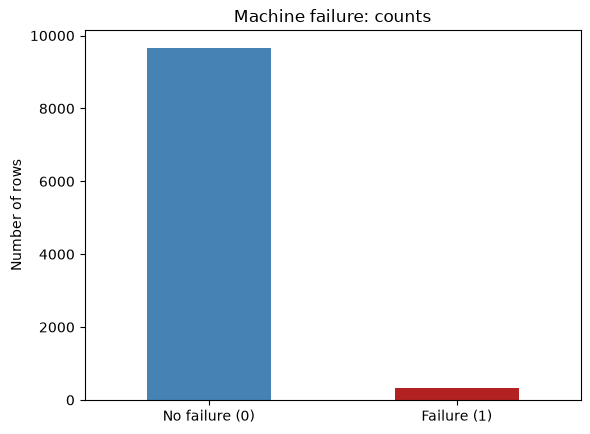

In [4]:
counts = df[TARGET].value_counts().sort_index()
counts.index = ["No failure (0)", "Failure (1)"]
print(counts)

counts.plot(kind="bar", title="Machine failure: counts", color=["steelblue", "firebrick"])
plt.ylabel("Number of rows")
plt.xticks(rotation=0)
plt.show()

## 4. Are there missing values?

**Why it matters:** real sensors drop readings, disconnect, or glitch. Missing values that aren't handled either crash the model or get silently dropped in a way you didn't choose. This dataset is simulated, so we expect zero - worth confirming, not assuming.

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values in any column.")
else:
    print(missing)

No missing values in any column.


## 5. What are the basic distributions of the sensor values?

**Why it matters:** distributions tell you the normal operating range for each sensor. A prediction pipeline should be able to sanity-check new readings against this range later (e.g. a torque reading 5x anything seen in training is more likely a sensor fault than a real signal). It also flags outliers or scaling differences between columns before they hit the model.

In [6]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
df[sensor_cols].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


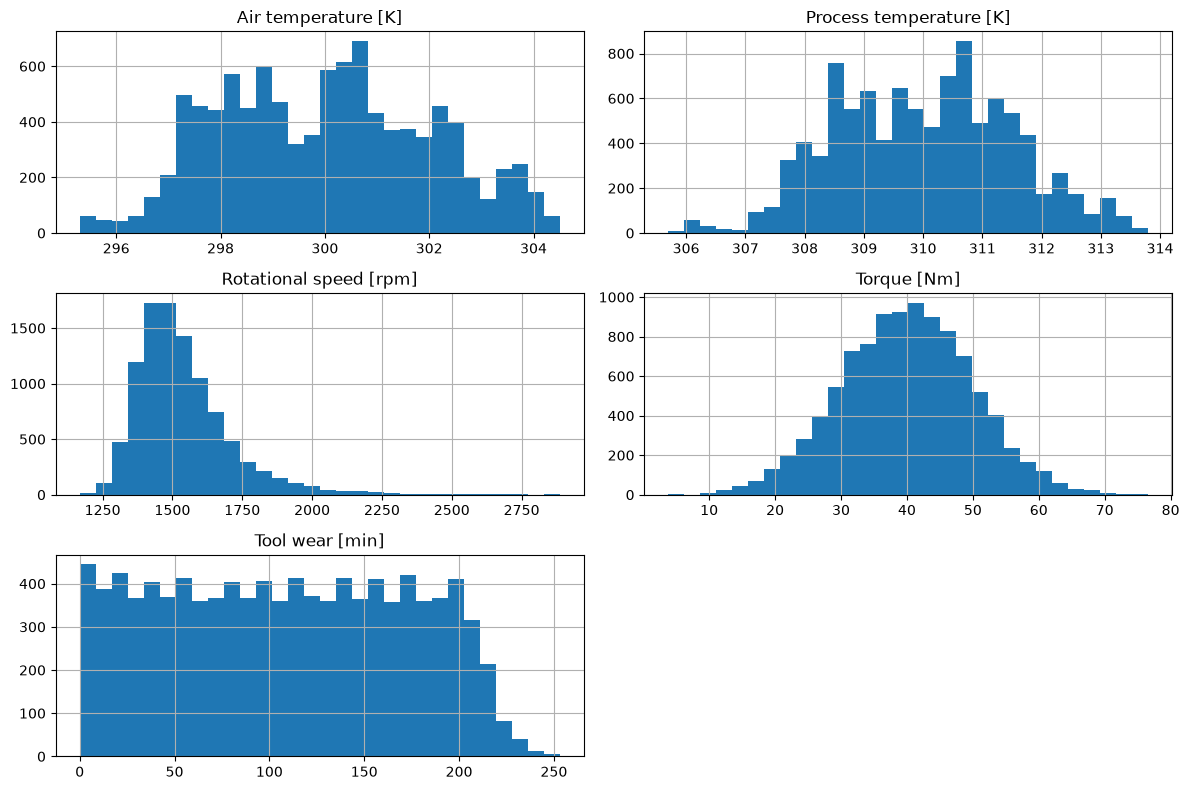

In [7]:
df[sensor_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

## 6. Is the target class imbalanced?

**Why it matters most:** this is the single biggest thing to understand before Stage 4/5. If failures are ~3% of rows, a model that always predicts "no failure" would score ~97% accuracy while catching zero real failures - useless for maintenance, where missing a failure is the expensive mistake. This is why accuracy alone won't be our evaluation metric (Stage 5) - we'll look at precision/recall on the failure class instead, and this is also why the deterministic rules layer (Stage 9) exists on top of the raw model output, not just the model's yes/no call.

In [8]:
pct = df[TARGET].value_counts(normalize=True) * 100
failure_rate = pct.get(1, 0.0)
print(f"Failure rate: {failure_rate:.2f}%")
print(f"Imbalance ratio (no-failure : failure): {(100 - failure_rate) / failure_rate:.1f} : 1")

Failure rate: 3.39%
Imbalance ratio (no-failure : failure): 28.5 : 1


## Summary

_(Fill in after running the cells above.)_

- Columns available: ...
- Target variable: `Machine failure`
- Failure vs non-failure counts: ...
- Missing values: ...
- Sensor ranges worth remembering: ...
- Imbalance ratio: ...